# 04 — Feature Engineering
**Goal:** Build the final feature tables for ALL three cohorts using the same pipeline.
Save to data/features/ as parquet files.

| Cohort | File | Use |
|--------|------|-----|
| 2024 Won → 2025 labels | train_2024.parquet | Training |
| 2025 Won → 2026 labels | test_2025.parquet  | Testing (partial labels) |
| 2025 Won (no labels)   | predict_2025.parquet | Live scoring |


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

from src.features.builder import build_cohort_features, get_feature_columns, build_labels
import pyarrow
FEATURES.mkdir(parents=True, exist_ok=True)


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)


## Build Training Dataset (2024 Won → 2025 labels)

In [2]:

train_df = build_cohort_features(bills, emails, cc, rc, renewal_year=2024, include_labels=True)
feature_cols = get_feature_columns(train_df)

print(f"Training features: {len(feature_cols)}")
print(f"Training rows: {len(train_df):,}")
print(f"Churn rate: {train_df['churn_label'].mean()*100:.2f}%")
print(f"scale_pos_weight: {(train_df['churn_label']==0).sum() / (train_df['churn_label']==1).sum():.1f}")


[2024] Base: 30,946 customers
[2024] Coverage — emails:29,203 cc:3,356 rc:18,595
[2024] Final: (30946, 99) ✓
[2024] Churn rate: 9.64%
Training features: 91
Training rows: 30,946
Churn rate: 9.64%
scale_pos_weight: 9.4


## Build Test Dataset (2025 Won → 2026 labels)

In [3]:

test_df = build_cohort_features(bills, emails, cc, rc, renewal_year=2025, include_labels=True)
print(f"Test rows: {len(test_df):,}")
decided = test_df['churn_label'].notna()
print(f"Customers with decided 2026 outcome: {decided.sum():,} ({decided.sum()/len(test_df)*100:.1f}%)")
print(f"Churn rate (decided only): {test_df.loc[decided,'churn_label'].mean()*100:.2f}%")


[2025] Base: 32,726 customers
[2025] Coverage — emails:31,538 cc:12,069 rc:23,722
[2025] Final: (32726, 99) ✓
[2025] Churn rate: 78.88%
Test rows: 32,726
Customers with decided 2026 outcome: 32,726 (100.0%)
Churn rate (decided only): 78.88%


## Feature Distribution: Train vs Test (distribution shift check)

In [4]:

# Check if the feature distributions are similar between train and test
# If very different, the model may not generalise well
shift_results = []
for col in feature_cols[:20]:  # check top 20 numeric features
    if col in train_df.columns and col in test_df.columns:
        tr = train_df[col].dropna()
        te = test_df[col].dropna()
        ks_stat, ks_p = stats.ks_2samp(tr, te)
        shift_results.append({
            'feature': col,
            'train_mean': round(tr.mean(), 4),
            'test_mean':  round(te.mean(), 4),
            'ks_stat': round(ks_stat, 4),
            'ks_p': round(ks_p, 4),
            'shifted': ks_p < 0.01
        })

shift_df = pd.DataFrame(shift_results).sort_values('ks_stat', ascending=False)
print("Features with potential distribution shift (p < 0.01):")
print(shift_df[shift_df['shifted']].to_string(index=False))
print(f"\nTotal shifted features: {shift_df['shifted'].sum()} / {len(shift_df)}")


Features with potential distribution shift (p < 0.01):
                 feature  train_mean  test_mean  ks_stat   ks_p  shifted
          Total_Net_Paid   1016.0417  1197.3897   0.1753 0.0000     True
          Connection_Qty      0.0000     0.7498   0.1313 0.0000     True
     Last_Total_Net_Paid    800.0273   879.2344   0.1051 0.0000     True
 Total_Renewal_Score_New     42.8473    43.5482   0.0880 0.0000     True
       Payment_Timeframe     -7.6706    -6.1992   0.0728 0.0000     True
      Auto_Renewal_Score      8.5076     8.5597   0.0521 0.0000     True
    Sustainability_Score      8.6731     8.7343   0.0463 0.0000     True
Renewal_Score_At_Release     25.9794    26.0366   0.0342 0.0000     True
      Current_Anchorings      3.3838     3.2198   0.0233 0.0000     True
         anchoring_3plus      0.3642     0.3422   0.0221 0.0000     True
            Tenure_Years      7.1067     7.2605   0.0191 0.0000     True
         #_of_Connection      3.5406     3.4158   0.0153 0.0011     T

## Null Check on Final Tables

In [5]:

for name, df in [('TRAIN', train_df), ('TEST', test_df)]:
    nulls = df[feature_cols].isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f"{name} — columns with nulls after fillna:")
        print(nulls)
    else:
        print(f"{name} — no nulls in feature columns ✓")


TRAIN — no nulls in feature columns ✓
TEST — no nulls in feature columns ✓


## Correlation Matrix of Final Features

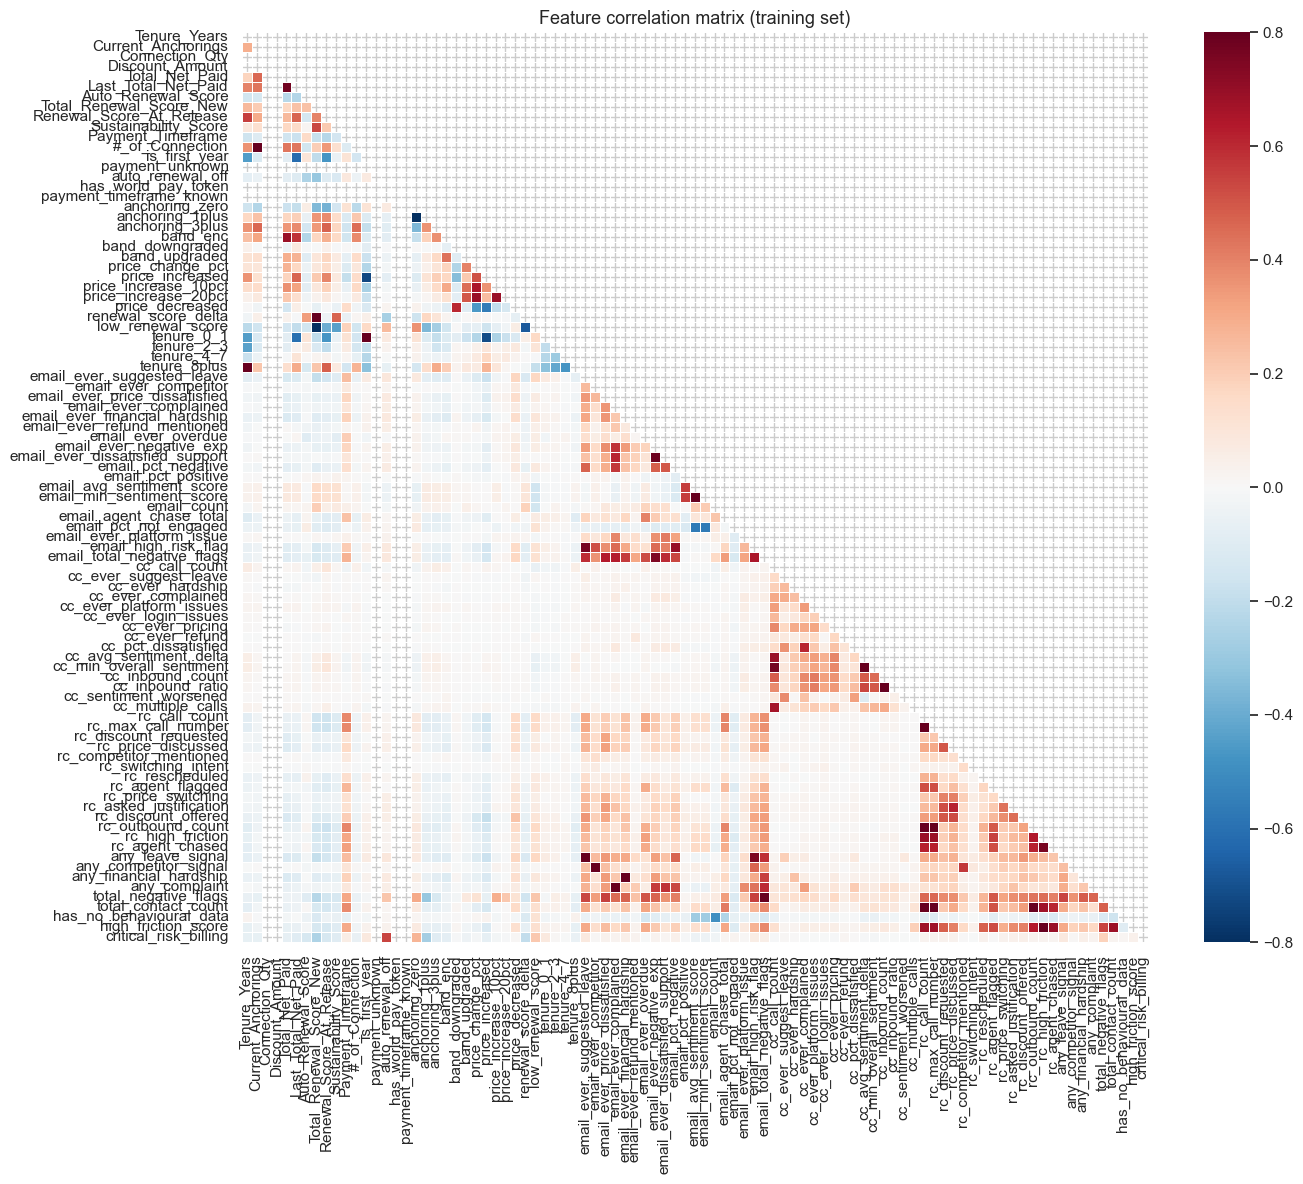

Highly correlated feature pairs (|corr| > 0.7):
  Tenure_Years vs tenure_8plus: 0.846
  Current_Anchorings vs #_of_Connection: 0.909
  Total_Net_Paid vs Last_Total_Net_Paid: 0.770
  Total_Renewal_Score_New vs renewal_score_delta: 0.862
  Total_Renewal_Score_New vs low_renewal_score: -0.824
  is_first_year vs price_increased: -0.725
  is_first_year vs tenure_0_1: 0.987
  anchoring_zero vs anchoring_1plus: -1.000
  price_increased vs tenure_0_1: -0.716
  email_ever_suggested_leave vs email_high_risk_flag: 0.765
  email_ever_suggested_leave vs any_leave_signal: 0.984
  email_ever_competitor vs any_competitor_signal: 0.860
  email_ever_complained vs any_complaint: 0.950
  email_ever_financial_hardship vs any_financial_hardship: 0.975
  email_ever_negative_exp vs email_ever_dissatisfied_support: 0.782
  email_ever_negative_exp vs email_total_negative_flags: 0.747
  email_avg_sentiment_score vs email_min_sentiment_score: 1.000
  email_high_risk_flag vs any_leave_signal: 0.753
  email_total_n

In [6]:

fig, ax = plt.subplots(figsize=(14, 12))
corr_matrix = train_df[feature_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-0.8, vmax=0.8, ax=ax, linewidths=0.5,
            xticklabels=True, yticklabels=True)
ax.set_title('Feature correlation matrix (training set)', fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / 'feature_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Highly correlated feature pairs (|corr| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        v = corr_matrix.iloc[i,j]
        if abs(v) > 0.7:
            print(f"  {corr_matrix.columns[i]} vs {corr_matrix.columns[j]}: {v:.3f}")


## Save All Feature Tables

In [7]:

def save_parquet(df, path):
    df_save = df.copy()
    # fix dtypes
    for col in df_save.select_dtypes(include='category').columns:
        df_save[col] = df_save[col].astype(str)
    for col in df_save.select_dtypes(include='Int64').columns:
        df_save[col] = df_save[col].fillna(0).astype(int)
    for col in df_save.select_dtypes(include='object').columns:
        df_save[col] = df_save[col].astype(str)
    df_save.to_parquet(path, index=False)
    print(f"Saved: {path.name} — {df_save.shape}")

save_parquet(train_df, FEATURES / 'train_2024.parquet')
save_parquet(test_df,  FEATURES / 'test_2025.parquet')

# save feature list
import json
with open(FEATURES / 'feature_cols.json', 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f"Feature columns saved ({len(feature_cols)} features)")

# print final summary
print()
print("=== FINAL DATASET SUMMARY ===")
print(f"Training set:  {len(train_df):,} rows × {len(feature_cols)} features | churn={train_df['churn_label'].mean()*100:.2f}%")
print(f"Test set:      {len(test_df):,} rows × {len(feature_cols)} features")


Saved: train_2024.parquet — (30946, 101)
Saved: test_2025.parquet — (32726, 101)
Feature columns saved (91 features)

=== FINAL DATASET SUMMARY ===
Training set:  30,946 rows × 91 features | churn=9.64%
Test set:      32,726 rows × 91 features
